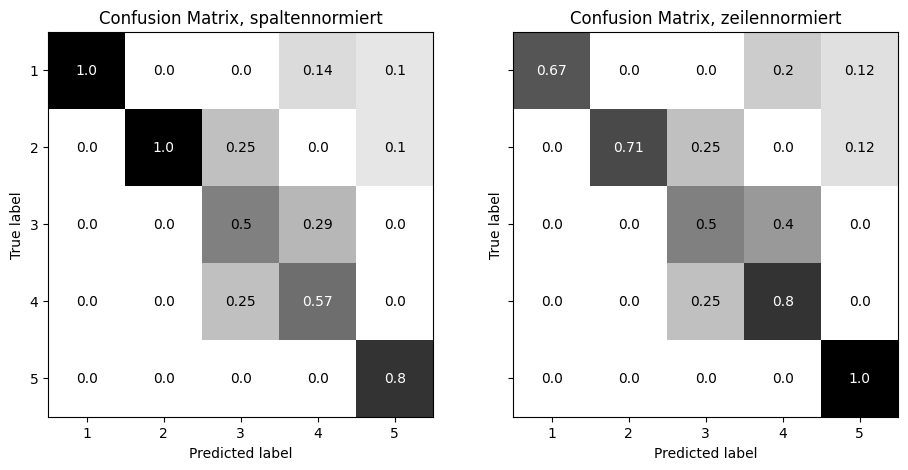

In [25]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from matplotlib import pyplot as plt

# --- Zufällige Datenmatrix ---
np.random.seed(420)
X, y = make_blobs(n_samples=150, centers=5, cluster_std=2.5, random_state=40)

# --- Aufteiling in train und test Daten ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

# --- Clusterung -> y_pred ---
K = 5
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# --- Visualisierung ---
# plt.scatter(*X_train.T, c=y_train, label="train")
# plt.scatter(*X_test.T, c=y_pred, marker="x", label="test")
# plt.legend()
# plt.show()

# --- Accuracy -> acc ---
acc = (y_pred == y_test).sum() / X_test.shape[0]

N = np.unique(y_pred).shape[0]
confusion_matrix = np.zeros((N, N))

for i, j in zip(y_test, y_pred):
    confusion_matrix[i-1, j-1] += 1

# --- Visualisierung ---
# from matplotlib import colors
# cmap=colors.ListedColormap(['black'])
# c = confusion_matrix > (confusion_matrix.max() / 2)
# for i in range(N):
#     for j in range(N):
#         plt.text(j, i, confusion_matrix[i, j], ha="center", va="center", c=(1,1,1) if c[i, j] else (0,0,0))
# plt.imshow(confusion_matrix, alpha=confusion_matrix/confusion_matrix.max(), cmap=cmap)
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted label")
# plt.ylabel("True label")
# plt.xticks(range(N), range(1, N+1))
# plt.yticks(range(N), range(1, N+1))
# plt.show()

# --- Spaltennormierung ---
confusion_matrix_spaltennormiert = confusion_matrix / confusion_matrix.sum(axis=0)

# --- Zeilennormierung ---
confusion_matrix_zeilennormiert = confusion_matrix / confusion_matrix.sum(axis=1)

# --- Visualisierung ---
# fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
# axs[0].imshow(confusion_matrix_spaltennormiert, alpha=confusion_matrix_spaltennormiert, cmap=cmap)
# axs[1].imshow(confusion_matrix_zeilennormiert, alpha=confusion_matrix_zeilennormiert, cmap=cmap)
# c = confusion_matrix_spaltennormiert > 0.5
# for i in range(N):
#     for j in range(N):
#         axs[0].text(j, i, confusion_matrix_spaltennormiert[i, j].round(2), ha="center", va="center", c=(1,1,1) if c[i, j] else (0,0,0))
# c = confusion_matrix_zeilennormiert > 0.5
# for i in range(N):
#     for j in range(N):
#         axs[1].text(j, i, confusion_matrix_zeilennormiert[i, j].round(2), ha="center", va="center", c=(1,1,1) if c[i, j] else (0,0,0))
# axs[0].set_title("Confusion Matrix, spaltennormiert")
# axs[0].set_xlabel("Predicted label")
# axs[0].set_ylabel("True label")
# axs[0].set_xticks(range(N), range(1, N+1))
# axs[0].set_yticks(range(N), range(1, N+1))
# axs[1].set_title("Confusion Matrix, zeilennormiert")
# axs[1].set_xlabel("Predicted label")
# axs[1].set_ylabel("True label")
# axs[1].set_xticks(range(N), range(1, N+1))
# axs[1].set_yticks(range(N), range(1, N+1))
# plt.show()